
# Caso de negocio clasificación de clientes
## Modelo RFM - Modelo K- Means


# Fase Importación de Datos


In [1]:
## Importar librerias

import pandas as pd #Para manipulación de datos
import numpy as np #Para operaciones matemáticas 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Ajustes para que los gráficos se vean bien y los números no salgan en notación científica
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
pd.options.display.float_format = "{:,.0f}".format

print("✅ Librerías listas. ¡A trabajar!")


✅ Librerías listas. ¡A trabajar!


---
##  Paso 2 — Cargar los datos (concepto de "base de datos")

Una **base de datos** es simplemente información organizada en **tablas** (filas y columnas), como una hoja de Excel. Las empresas tienen muchas tablas separadas que se **relacionan** entre sí mediante códigos.

En nuestro caso tenemos **3 tablas**:

| Tabla | Qué contiene | Tamaño |
|-------|--------------|--------|
| `usos_parques` | Cada ingreso de cada persona | ~225 mil filas |
| `Sedes` | Qué parque es cada código | 16 filas |
| `Productos` | Qué producto es cada código | 6 filas |

La tabla grande guarda `codsede=721` en vez de "Parque Copacabana" para ahorrar espacio. Más adelante las **uniremos** (eso se llama `merge`, como un BUSCARV de Excel).


In [9]:
# Cargamos la tabla principal de ingresos a los parques
df_parques = pd.read_csv("usos_parques_2024_2025.csv")

print(f"La tabla principal tiene {df_parques.shape[0]:,} filas y {df_parques.shape[1]} columnas")
df_parques.head()

La tabla principal tiene 79,117 filas y 12 columnas


,code_anon,genero,fechanacimiento,fecha,hora,codsede,codproducto,valor_neto,valor_descuento,tarifa,grupo,tipo_venta
0,ID_d91be8edb096,Femenino,1977-01-09,2025-05-25,11,721,24,0,4700,TA,Cortesias web 2-Apl,Individual
1,ID_6d1b7b46e8f8,Masculino,1971-12-20,2025-05-25,11,722,24,"4,800",0,TB,NaN,Individual
2,ID_565bd74de162,Masculino,1963-10-28,2025-05-25,8,721,24,"21,400",0,TC,Adulto mayor no afi. parques,Individual
3,ID_ca7d0706f01b,Femenino,2006-03-16,2025-05-25,10,723,504,"3,100",0,TB,NaN,Individual
4,ID_b7edbab69874,Femenino,1988-02-07,2025-05-25,16,723,504,"4,300",0,TC,NaN,Individual


In [10]:
# Cargamos la tabla principal 2 de ingresos a los parques

df_parques2 = pd.read_csv("usos_parques_2024_2025.2.csv")

print(f"La tabla principal 2 tiene {df_parques2.shape[0]:,} filas y {df_parques2.shape[1]} columnas")
df_parques2.head()

La tabla principal 2 tiene 225,682 filas y 12 columnas


,code_anon,genero,fechanacimiento,fecha,hora,codsede,codproducto,valor_neto,valor_descuento,tarifa,grupo,tipo_venta
0,ID_9301202a1548,Masculino,2014-04-28,2024-01-02,9,721,24,"4,500",0,TA,NaN,Individual
1,ID_7f5174f88b44,Femenino,1985-11-29,2024-01-02,9,721,24,"4,500",0,TA,NaN,Individual
2,ID_06a5d7f57dc2,Masculino,2012-07-21,2024-01-02,13,723,24,"4,500",0,TA,NaN,Individual
3,ID_d7a80202670e,Masculino,1975-07-17,2024-01-02,9,721,24,"4,500",0,TA,NaN,Individual
4,ID_bcf0ee23d281,Masculino,1997-12-23,20240102,11,779,24,"6,500",0,TB,NaN,Individual


In [13]:
# Cargamos las tablas de catálogo (el "diccionario" de códigos)

sedes     = pd.read_excel("codigos_sedes_producto.xlsx", sheet_name="Sedes")
productos = pd.read_excel("codigos_sedes_producto.xlsx", sheet_name="Productos")


In [14]:
sedes.head()

,codsede,sede
0,721,Administracion copacabana
1,722,Administracion la estrella
2,723,Administracion Rionegro
3,724,Administracion guatape
4,779,Administracion parque arvi


In [15]:
productos.head()

,codproducto,strdescripcionproducto
0,24,Ing. parque
1,136,Ingreso nocturno
2,145,Brazalete todo parque interno
3,504,Eventos Tutucan
4,1109,"Paquete Ingreso Nocturno. Aplica Rionegro, Est..."


In [16]:
df_parques.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79117 entries, 0 to 79116
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   code_anon        79117 non-null  object 
 1   genero           79117 non-null  object 
 2   fechanacimiento  79117 non-null  object 
 3   fecha            79117 non-null  object 
 4   hora             79117 non-null  float64
 5   codsede          79117 non-null  float64
 6   codproducto      79117 non-null  float64
 7   valor_neto       79117 non-null  float64
 8   valor_descuento  79117 non-null  int64  
 9   tarifa           79117 non-null  object 
 10  grupo            36865 non-null  object 
 11  tipo_venta       79117 non-null  object 
dtypes: float64(4), int64(1), object(7)
memory usage: 7.2+ MB


In [17]:
df_parques2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225682 entries, 0 to 225681
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   code_anon        225682 non-null  object 
 1   genero           225682 non-null  object 
 2   fechanacimiento  225682 non-null  object 
 3   fecha            225682 non-null  object 
 4   hora             225682 non-null  float64
 5   codsede          225682 non-null  float64
 6   codproducto      225682 non-null  float64
 7   valor_neto       225682 non-null  float64
 8   valor_descuento  225682 non-null  int64  
 9   tarifa           225682 non-null  object 
 10  grupo            95833 non-null   object 
 11  tipo_venta       225682 non-null  object 
dtypes: float64(4), int64(1), object(7)
memory usage: 20.7+ MB


# Paso 3 — Limpieza de datos (el trabajo invisible pero esencial)

## Vamos a revisar y arreglar problema por problema.

## 3.1 — Columnas de texto sucias (espacios y mayúsculas)
### Miremos la columna tarifa:



In [19]:
# .unique() muestra todos los valores distintos
print("Valores ÚNICOS de 'tarifa' (datos crudos):")
print(df_parques["tarifa"].unique())

Valores ÚNICOS de 'tarifa' (datos crudos):
['TA' 'TB' 'TC' 'Abierto al Público' 'TD' 'ta' ' ta ' 'TA  ' 'TA ' 'TD  '
 'abierto al   público' '  TA  ' ' TD ' ' ta  ' 'ABIERTO AL PÚBLICO  '
 '  TA' '  TD ' ' Abierto al Pú  blico' 'ta ' 'ABIERTO AL PÚBLICO' ' td'
 ' abierto al público ' '  ta  ' '  TA ' ' TA ' ' TD' ' TB ' '  TD' ' TA'
 'ABIE  RTO AL PÚBLICO  ' ' TA    ' '  Abierto al Publico' 'TC  '
 'abierto al público' 'td' '    TD  ' '  TB' ' TC'
 '  Abi  erto al Público' '  t  a  ' 'ta  ' 'td ' ' TB'
 ' Abi  erto al Público' '  T  A  ' '  tb' 'Abierto al Publico' '  ta '
 '  TB ' ' Abierto al Publico' '  TB  ' 'Abierto al Públ  ico' ' TA  '
 ' tb' '    TA  ' '  abierto al público' 'TB  ' '  td  ' '    ta  ' '  ta'
 '    TA ' '  Abierto al Público' 'A  bierto al Publico ' ' ta' 'TC '
 'TD ' '    ta ' ' Abierto al Público ' '  TC' 'Abiert  o al Público '
 'Abierto al Público  ' 'tb' '  TC ' 'ABIERTO AL PÚBLICO ' 'tc  '
 '  T  A ' ' Abierto al Publico ' ' TC ' ' tb  ' 'Ab  ierto al Publ

In [20]:
# .unique() muestra todos los valores distintos
print("Valores ÚNICOS de 'tarifa' (datos crudos):")
print(df_parques2["tarifa"].unique())

Valores ÚNICOS de 'tarifa' (datos crudos):
['TA' ' TB' 'TD' 'TB' 'TC' 'ABIERTO AL PÚBLICO' 'ta' ' TD' ' T  B  ' 'tc'
 'tb' 'td  ' 'TA ' '  TD' 'Abierto al Público' '  ta' ' TA ' ' TA' '  tb'
 'ta ' '  TB' '  TA ' 'TA  ' ' TA  ' '  TA  ' ' TC ' '  TA' 'ta  ' 'td '
 '    TA ' '   TD  ' '  TD  ' 'TD ' 'TB ' ' ta' ' TC    ' ' td ' 'TD  '
 '  t  c ' '  TB  ' ' tc' '  TD    ' ' T  A  ' 'td' '  T  A ' '  td'
 '    TA  ' 'TC ' '  ta  ' 'TB  ' ' TC' '  TC' 'ab  ierto al público '
 'TC  ' '  tc ' '  TC  ' ' ta  ' '    td  ' ' TD ' '  tc'
 'ABIERTO   AL PÚBLICO ' ' TC  ' ' ta ' ' TD    ' ' TB    ' 'tb  ' ' TB '
 'abierto al público' '    TD  ' 'tc  ' 'tb ' ' td  ' ' tb' '    TB '
 ' Abierto al Público  ' 'abierto al público  ' ' ABIERTO AL PÚBLICO'
 '  ta ' '    TD ' ' tb ' '  TA    ' '  TC ' ' TD  '
 ' Abierto al Público ' ' TB  ' ' tb  ' '   TA  ' 'abierto al pú  blico'
 '  tc  ' 'tc ' '  Abierto al Público' '    td ' '    ta  '
 'Abierto   al Público  ' 'Abierto al Publico' 'ABIERTO AL PÚBLICO

In [21]:
# .unique() muestra todos los valores distintos
print("Valores ÚNICOS de 'tipo de venta' (datos crudos):")
print(df_parques2["tipo_venta"].unique())

Valores ÚNICOS de 'tipo de venta' (datos crudos):
['Individual' 'Individ  ual  ' 'INDIVIDUAL ' '  individual ' ' Individual'
 'i  ndividual' ' individual  ' 'INDIVIDUAL' 'individual' 'individual '
 '  INDIVIDUAL' '  individual  ' 'Individual ' ' INDIVIDUAL'
 '  Individu  al' '  Indiv  idual' 'Empresarial' '  INDIVIDU  AL'
 '  individual' 'indivi  dual' '    Individual' 'Indi  vidual  '
 'INDIVIDUAL  ' ' Individual  ' ' Individual ' '  In  dividual'
 '  Individual' '  Indivi  dual  ' 'IN  DIVIDUAL ' 'INDIVID  UAL'
 ' individual' 'I  ndividual' ' IN  DIVIDUAL  ' 'IND  IVIDUAL  '
 'Individual  ' ' Individua  l ' '  Individual ' 'Individu  al'
 ' INDIVIDUAL    ' 'individual  ' ' INDIVIDUAL  ' '   Individual'
 '  Individual  ' ' ind  ividual ' 'Individua  l ' 'Ind  ividual'
 ' individual ' 'individ  ual ' '  In  dividual  ' 'Indiv  idual'
 '  INDIVIDUAL  ' 'Ind  ividual  ' ' Indiv  idual  ' '  Individu  al  '
 'Indi  vidual' ' indi  vidual' '  Indivi  dual ' '  individu  al'
 'INDIVIDU  AL 

## Solución: quitar espacios (.str.strip()) y poner todo en mayúsculas (.str.upper()).
## Adicionalmente se quitan las tildes para evitar problemas
## Hay que mejorar los espacios

# Crear Función para limpiar texto

In [31]:

## Crear función para limpiar texto (tarifa y tipo_venta)

import unicodedata
 
def limpiar_texto(serie):
    # quitar los espacios sobrantes (incluso internos dobles), normalizar mayúsculas y quitar tildes
    return (serie.astype(str)
                 .str.normalize("NFKC") # Convierte espacios "raros", los que aparecen dentro de la misma palabra, a espacios normales
                 .str.strip()           # quita espacios al inicio y al final
                 .str.replace(r"\s+", "", regex=True)  # espacios dobles -> uno
                 .str.upper()  #pone todo en mayúsculas
                 .str.normalize("NFKD") # Separa letras de tildes (ayuda a identificar los acentos)
                 .str.encode("ascii", "ignore") # Elimina caracteres no ASCII (tildes)
                 .str.decode("utf-8")
                 )

df_parques["tarifa"]     = limpiar_texto(df_parques["tarifa"])
df_parques["tipo_venta"] = limpiar_texto(df_parques["tipo_venta"])

print("Tarifa DESPUÉS de limpiar (parques):")
print(df_parques["tarifa"].unique())

Tarifa DESPUÉS de limpiar (parques):
['TA' 'TB' 'TC' 'ABIERTOALPUBLICO' 'TD']


In [32]:
df_parques2["tarifa"]     = limpiar_texto(df_parques2["tarifa"])
df_parques2["tipo_venta"] = limpiar_texto(df_parques2["tipo_venta"])

print("Tarifa DESPUÉS de limpiar (parques2):")
print(df_parques2["tarifa"].unique())

Tarifa DESPUÉS de limpiar (parques2):
['TA' 'TB' 'TD' 'TC' 'ABIERTOALPUBLICO']


In [33]:
print("\nTipo de venta DESPUÉS de limpiar (parques2):")
print(df_parques2["tipo_venta"].unique())



Tipo de venta DESPUÉS de limpiar (parques2):
['INDIVIDUAL' 'EMPRESARIAL']


## 3.2 — Convertir las fechas a formato real
### Las fechas vienen en formatos mezclados. Le pedimos a pandas que las interprete:

In [34]:
df_parques["fecha"].head()


0    2025-05-25
1    2025-05-25
2    2025-05-25
3    2025-05-25
4    2025-05-25
Name: fecha, dtype: object

In [35]:
df_parques2["fecha"].head()


0    2024-01-02
1    2024-01-02
2    2024-01-02
3    2024-01-02
4      20240102
Name: fecha, dtype: object

In [36]:
# fecha de necimiento

nac = df_parques["fechanacimiento"].astype(str).str.strip()  #quita espacios
nac2 = df_parques2["fechanacimiento"].astype(str).str.strip()  #quita espacios

nac = nac.str.replace(r"\s+", "-", regex=True)  #quita guión de fecha
nac2 = nac2.str.replace(r"\s+", "-", regex=True)  #quita guión de fecha

df_parques["fechanacimiento"] = pd.to_datetime(nac, format="mixed", errors="coerce")  # 'mixed' = pandas detecta el formato de cada fila;
df_parques2["fechanacimiento"] = pd.to_datetime(nac2, format="mixed", errors="coerce")  # 'mixed' = pandas detecta el formato de cada fila;



In [37]:
df_parques["fechanacimiento"].head()

0   1977-01-09
1   1971-12-20
2   1963-10-28
3   2006-03-16
4   1988-02-07
Name: fechanacimiento, dtype: datetime64[ns]

In [38]:
df_parques2["fechanacimiento"].head()

0   2014-04-28
1   1985-11-29
2   2012-07-21
3   1975-07-17
4   1997-12-23
Name: fechanacimiento, dtype: datetime64[ns]

In [39]:
# Corregimos columna "fecha". Hay 3 formatos mezclados: CASO 1 aaaammdd, CASO 2 aaaa-mm-dd, CASO 3 mm/dd/aaaa

df_parques["fecha"] = pd.to_datetime(df_parques["fecha"], format="mixed", errors="coerce")

print("Rango de fechas de visita:", df_parques["fecha"].min().date(), "→", df_parques["fecha"].max().date())


Rango de fechas de visita: 2024-01-02 → 2025-12-30


In [48]:
f = df_parques["fecha"].astype(str).str.strip()  #quita espacios


mask8 = f.str.fullmatch(r"\d{8}") # definimos 8 caracteres 
f = f.where(~mask8, f.str.slice(0, 4) + "-" + f.str.slice(4, 6) + "-" + f.str.slice(6, 8)) # si tiene 8 caracteres, le agregamos guiones 

slash= f.str.contains("/", na=False) # detectamos si tiene slash - normalizamos el formato / y -

fecha_final = pd.Series(pd.NaT, index=f.index, dtype="datetime64[ns]") # creamos una serie vacía para guardar las fechas finales

fecha_final[slash] = pd.to_datetime(f[slash], format="%m/%d/%Y", errors="coerce") # si tiene slash, lo convertimos a datetime

fecha_final[~slash] = pd.to_datetime(f[~slash], format="%Y-%m-%d", errors="coerce") # si no tiene slash, lo convertimos a datetime

# Reemplazamos fecha antigua por fecha final
df_parques["fecha"] = fecha_final

df_parques["fecha"].value_counts()

fecha
2025-06-29    1912
2025-06-22    1599
2025-06-30    1457
2025-06-01    1327
2025-09-21    1301
              ... 
2025-02-04       1
2024-05-02       1
2024-03-06       1
2024-02-08       1
2024-03-11       1
Name: count, Length: 671, dtype: int64

In [49]:
df_parques["fecha"].head()


0   2025-05-25
1   2025-05-25
2   2025-05-25
3   2025-05-25
4   2025-05-25
Name: fecha, dtype: datetime64[ns]

In [ ]:
# Limpieza de fecha para la tabla 2 y unificación de ambos datasets en 'df'
df_parques2['fecha'] = pd.to_datetime(
    df_parques2['fecha'].astype(str).str.replace(r'\.0$', '', regex=True),
    format='mixed',
    errors='coerce'
)

# Unir ambas tablas de asistencia (2024 y 2025) en un único DataFrame consolidado 'df'
df = pd.concat([df_parques, df_parques2], ignore_index=True)

print(f"✅ Datasets unificados con éxito. Total filas en df: {df.shape[0]:,} | Columnas: {df.shape[1]}")
print(f"Rango global de fechas: {df['fecha'].min().date()} → {df['fecha'].max().date()}")

### 3.3 — Convertir valores a números y revisar nulos

In [11]:
# Pasar montos a número. Lo que no se pueda convertir queda como vacío (NaN)
df["valor_neto"]      = pd.to_numeric(df["valor_neto"], errors="coerce")
df["valor_descuento"] = pd.to_numeric(df["valor_descuento"], errors="coerce")

# ¿Cuántos datos faltantes (nulos) hay por columna?
print("Datos faltantes por columna:")
print(df.isna().sum())

Datos faltantes por columna:
code_anon               0
genero                  0
fechanacimiento         0
fecha                   0
hora                    0
codsede                 0
codproducto             0
valor_neto              0
valor_descuento         0
tarifa                  0
grupo              129849
tipo_venta              0
dtype: int64


La columna `grupo` tiene muchos vacíos, pero eso **tiene sentido**: solo se llena cuando la persona entra con un grupo. No todo vacío es un error — hay que **pensar** qué significa.

### 3.4 — Crear nuevas columnas útiles (Feature Engineering)
Una habilidad clave: **inventar columnas nuevas** a partir de las que tenemos. Aquí calculamos la **edad** de cada visitante, que será oro para segmentar.

In [12]:
# Edad = (fecha de visita - fecha de nacimiento) en años
df["edad"] = ((df["fecha"] - df["fechanacimiento"]).dt.days / 365.25)

# Hay edades imposibles (negativas o >110): las marcamos como vacías
df.loc[(df["edad"] < 0) | (df["edad"] > 110), "edad"] = np.nan

# Columnas de calendario, muy útiles para ver tendencias
df["anio"]        = df["fecha"].dt.year
df["mes"]         = df["fecha"].dt.to_period("M").astype(str)
df["dia_semana"]  = df["fecha"].dt.day_name()

print("Edad promedio de los visitantes:", round(df["edad"].mean(), 1), "años")
df[["fecha", "edad", "anio", "mes", "dia_semana"]].head()

Edad promedio de los visitantes: 32.1 años


,fecha,edad,anio,mes,dia_semana
0,2024-01-02,10,2024,2024-01,Tuesday
1,2024-01-02,38,2024,2024-01,Tuesday
2,2024-01-02,11,2024,2024-01,Tuesday
3,2024-01-02,48,2024,2024-01,Tuesday
4,2024-01-02,26,2024,2024-01,Tuesday


### 3.5 — Unir las tablas (el "BUSCARV" de Python)
Reemplazamos los códigos por nombres legibles uniendo con las tablas de catálogo.


In [13]:
# merge = pegar columnas de otra tabla usando una llave común (el código)
df = df.merge(sedes,     on="codsede",     how="left")
df = df.merge(productos, on="codproducto", how="left")

df[["codsede", "sede", "codproducto", "strdescripcionproducto"]].head()

,codsede,sede,codproducto,strdescripcionproducto
0,721,Administracion copacabana,24,Ing. parque
1,721,Administracion copacabana,24,Ing. parque
2,723,Administracion Rionegro,24,Ing. parque
3,721,Administracion copacabana,24,Ing. parque
4,779,Administracion parque arvi,24,Ing. parque


## 📊 Análisis descriptivo y de calidad de datos en 1 línea (CLASE PRESENCIAL 25/06/2026)
### La librería `ydata-profiling` | Aplicación de Gabriela Parada

---

### ¿Qué vamos a aprender hoy?

En clases anteriores limpiamos los datos de los parques "a mano": revisamos nulos, formatos de fecha, texto sucio... y nos tomó varias celdas. Hoy aprenderemos una herramienta que hace **gran parte de ese trabajo automáticamente** y genera un **reporte profesional** en segundos.

### ¿Qué nos dirá el reporte automático?
- Cuántas filas, columnas y datos faltan
- El tipo y la distribución de cada variable
- Valores duplicados y datos sospechosos
- Correlaciones entre variables
- Alertas de calidad (¡esto es lo más valioso!)


-----
### Paso 0 — Perfilar datos 
 **chequeo general**

 `ydata-profiling`: Le pasas el dataset y te devuelve un informe con el "estado de salud" de cada columna y una lista de **alertas** (datos faltantes, valores raros, duplicados).

**¿Por qué es importante?** Porque antes de analizar o modelar, necesitas *conocer* tus datos. Saltarse este paso es como recetar sin diagnosticar. Y hacerlo a mano, columna por columna, es lento. Esta librería te da el diagnóstico completo de entrada.



---
### Paso 1 — Instalar la librería

La librería no viene con Python por defecto: hay que instalarla una sola vez en nuestro ambiente virtual (el que creamos en la guía anterior).

**Asegúrate de tener tu ambiente activado** (debe verse `(venv)` en la terminal). Luego ejecuta la celda de abajo, o corre el comando en la terminal sin el signo `!`.

Esto se hizo en la clase - Aquí se verificará si la librería está instalada:




In [ ]:
import pandas as pd

# Profiling opcional: si está instalado genera el reporte, de lo contrario continúa sin error
try:
    from ydata_profiling import ProfileReport
    print("ydata_profiling disponible.")
except ImportError:
    print("Nota: ydata_profiling no está instalado en este entorno. Continuamos con el análisis exploratorio estándar (EDA).")


---
##  Paso 4 — EDA: Análisis Exploratorio de Datos

**EDA = "conocer a fondo nuestros datos antes de sacar conclusiones".** Es como un médico que examina al paciente antes de recetar. Buscamos: ¿cómo se distribuyen?, ¿hay tendencias?, ¿qué patrones esconden?

Cada gráfico que hagamos buscará responder una de nuestras 3 preguntas de negocio.

### 4.1 — ¿Quiénes nos visitan? (Edad y género)

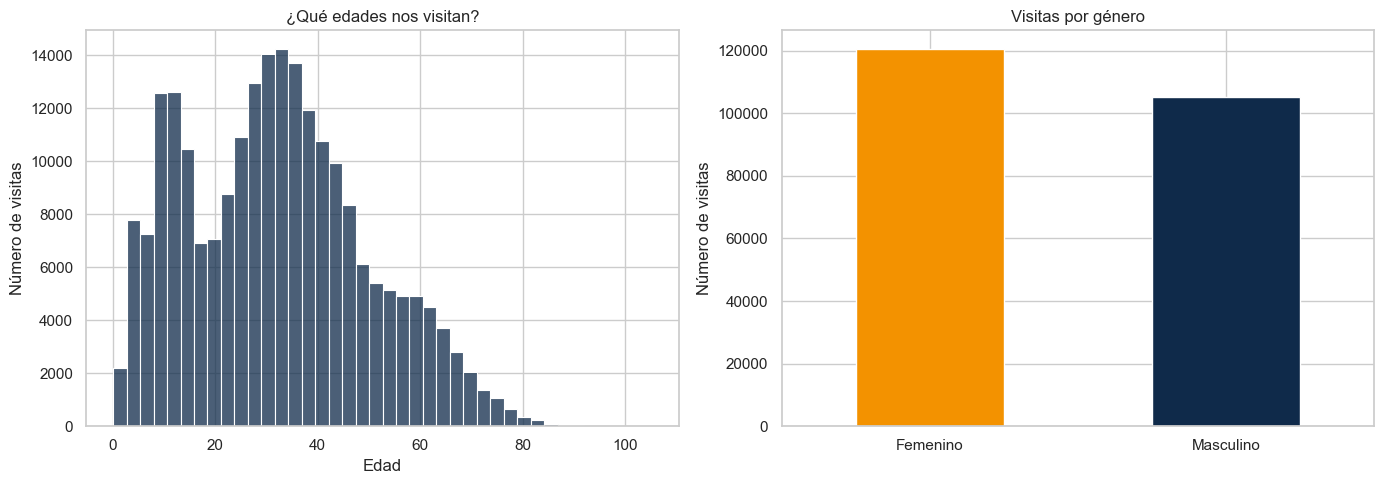

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de edades
sns.histplot(df["edad"].dropna(), bins=40, ax=axes[0], color="#0F2A4A")
axes[0].set_title("¿Qué edades nos visitan?")
axes[0].set_xlabel("Edad"); axes[0].set_ylabel("Número de visitas")

# Visitas por género
df["genero"].value_counts().plot(kind="bar", ax=axes[1], color=["#F39200", "#0F2A4A"])
axes[1].set_title("Visitas por género")
axes[1].set_xlabel(""); axes[1].set_ylabel("Número de visitas")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout(); plt.show()

**Cómo se lee:** El público es mayoritariamente joven-adulto. Identificar los grupos de edad dominantes nos dice a quién ya estamos llegando — y por contraste, a quién **no** (oportunidad de atracción).

### 4.2 — ¿Cómo evolucionan las visitas en el tiempo? (Tendencia)
Esta es la pregunta clave del negocio: *"¿estamos perdiendo gente?"*

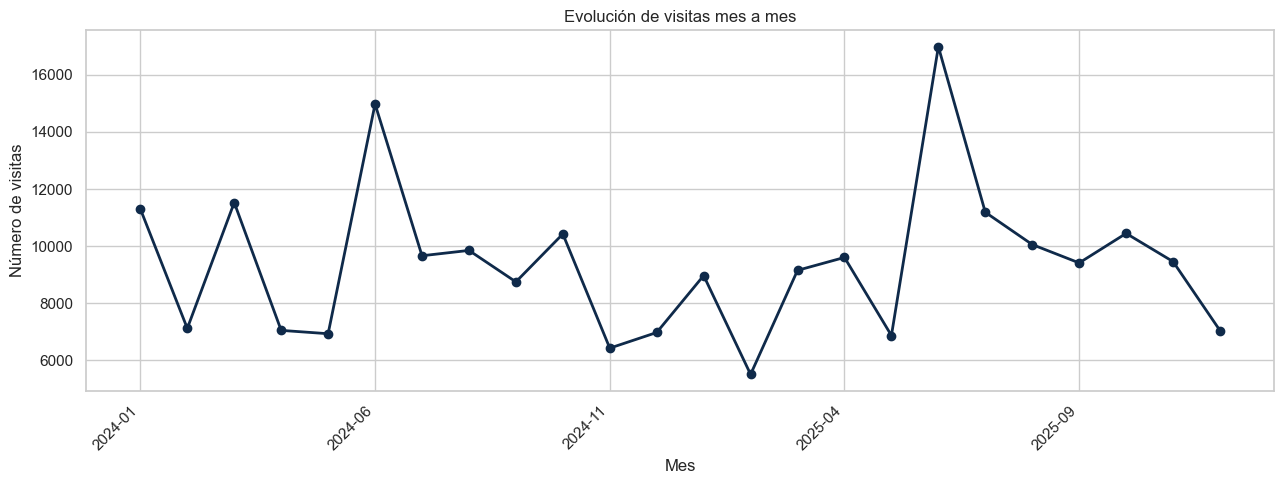

In [15]:
visitas_mes = df.groupby("mes").size()

plt.figure(figsize=(13, 5))
visitas_mes.plot(marker="o", color="#0F2A4A", linewidth=2)
plt.title("Evolución de visitas mes a mes")
plt.xlabel("Mes"); plt.ylabel("Número de visitas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()